In [88]:
import joblib
import pandas as pd
import numpy as np
import seaborn as sns 
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from catboost import CatBoostClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)
from xgboost import XGBClassifier
from sklearn.metrics import classification_report

In [2]:
df = pd.read_csv("predictive_maintenance_v3.csv")

# problem defination + data explore

In [3]:
df.shape

(24042, 15)

In [4]:
df.head()

,timestamp,machine_id,machine_type,vibration_rms,temperature_motor,current_phase_avg,pressure_level,rpm,operating_mode,hours_since_maintenance,ambient_temp,rul_hours,failure_within_24h,failure_type,estimated_repair_cost
0,2024-01-01 00:00:00,1,CNC,0.81,49.51,5.10,23.6,860.9,idle,273.80,13.9,61.00,0,none,0
1,2024-01-01 00:03:00,1,CNC,0.75,40.58,5.30,23.6,899.6,idle,273.85,10.2,60.95,0,none,0
2,2024-01-01 00:21:00,1,CNC,0.71,49.70,NaN,21.3,862.7,idle,274.15,13.6,60.65,0,none,0
3,2024-01-01 00:45:00,1,CNC,0.76,43.04,4.79,22.6,870.4,idle,274.55,13.4,60.25,0,none,0
4,2024-01-01 00:54:00,1,CNC,0.88,41.39,4.44,22.2,881.9,idle,274.70,10.8,60.10,0,none,0


In [5]:
df.tail()

,timestamp,machine_id,machine_type,vibration_rms,temperature_motor,current_phase_avg,pressure_level,rpm,operating_mode,hours_since_maintenance,ambient_temp,rul_hours,failure_within_24h,failure_type,estimated_repair_cost
24037,2024-01-14 22:17:56,20,Robotic Arm,0.98,37.18,5.27,45.0,361.8,normal,163.43,10.2,0.5,0,none,0
24038,2024-01-14 22:41:56,20,Robotic Arm,0.45,33.90,2.21,18.9,159.5,idle,163.83,11.0,0.5,0,none,0
24039,2024-01-14 22:58:56,20,Robotic Arm,0.40,29.15,2.29,19.0,159.5,idle,164.12,16.2,0.5,0,none,0
24040,2024-01-14 23:23:56,20,Robotic Arm,0.45,31.47,2.45,18.0,151.4,idle,164.53,16.7,0.5,0,none,0
24041,2024-01-14 23:52:56,20,Robotic Arm,0.44,33.73,2.25,14.8,153.4,idle,165.02,9.2,0.5,0,none,0


In [6]:
df.isnull().sum()

timestamp                     0
machine_id                    0
machine_type                  0
vibration_rms              1000
temperature_motor           834
current_phase_avg           731
pressure_level              924
rpm                         533
operating_mode                0
hours_since_maintenance       0
ambient_temp                  0
rul_hours                     0
failure_within_24h            0
failure_type                  0
estimated_repair_cost         0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 24042 entries, 0 to 24041
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   timestamp                24042 non-null  str    
 1   machine_id               24042 non-null  int64  
 2   machine_type             24042 non-null  str    
 3   vibration_rms            23042 non-null  float64
 4   temperature_motor        23208 non-null  float64
 5   current_phase_avg        23311 non-null  float64
 6   pressure_level           23118 non-null  float64
 7   rpm                      23509 non-null  float64
 8   operating_mode           24042 non-null  str    
 9   hours_since_maintenance  24042 non-null  float64
 10  ambient_temp             24042 non-null  float64
 11  rul_hours                24042 non-null  float64
 12  failure_within_24h       24042 non-null  int64  
 13  failure_type             24042 non-null  str    
 14  estimated_repair_cost    24042 no

In [9]:
df.describe()

,machine_id,vibration_rms,temperature_motor,current_phase_avg,pressure_level,rpm,hours_since_maintenance,ambient_temp,rul_hours,failure_within_24h,estimated_repair_cost
count,24042.000000,23042.000000,23208.000000,23311.000000,23118.000000,23509.000000,24042.000000,24042.000000,24042.000000,24042.000000,24042.000000
mean,10.505033,1.623667,51.404295,8.823829,59.012233,1144.849317,172.630624,12.996398,27.812510,0.148074,608.870144
std,5.746455,1.081061,12.519279,5.366391,38.723271,912.670971,150.722469,2.883994,26.393801,0.355181,1566.793887
min,1.000000,0.350000,28.000000,2.200000,10.100000,124.100000,0.000000,8.000000,0.500000,0.000000,0.000000
25%,6.000000,0.820000,42.610000,4.630000,22.700000,489.400000,42.870000,10.500000,0.500000,0.000000,0.000000
50%,10.000000,1.270000,50.060000,6.430000,46.300000,856.000000,121.610000,13.000000,22.570000,0.000000,0.000000
75%,15.000000,2.270000,59.962500,13.120000,94.700000,1676.000000,295.575000,15.500000,46.410000,0.000000,0.000000
max,20.000000,10.000000,95.000000,35.000000,206.500000,4098.800000,575.630000,18.000000,98.340000,1.000000,7995.000000


In [10]:
df.dtypes

timestamp                      str
machine_id                   int64
machine_type                   str
vibration_rms              float64
temperature_motor          float64
current_phase_avg          float64
pressure_level             float64
rpm                        float64
operating_mode                 str
hours_since_maintenance    float64
ambient_temp               float64
rul_hours                  float64
failure_within_24h           int64
failure_type                   str
estimated_repair_cost        int64
dtype: object

In [11]:
df.columns

Index(['timestamp', 'machine_id', 'machine_type', 'vibration_rms',
       'temperature_motor', 'current_phase_avg', 'pressure_level', 'rpm',
       'operating_mode', 'hours_since_maintenance', 'ambient_temp',
       'rul_hours', 'failure_within_24h', 'failure_type',
       'estimated_repair_cost'],
      dtype='str')

In [12]:
df["machine_type"].value_counts()

machine_type
Pump           6114
Robotic Arm    6003
Compressor     5988
CNC            5937
Name: count, dtype: int64

In [13]:
df["operating_mode"].value_counts()

operating_mode
normal    11632
idle      10862
peak       1548
Name: count, dtype: int64

In [14]:
df["failure_type"].value_counts()

failure_type
none              20482
bearing            1117
motor_overheat     1060
hydraulic           728
electrical          655
Name: count, dtype: int64

In [15]:
df["failure_within_24h"].value_counts()

failure_within_24h
0    20482
1     3560
Name: count, dtype: int64

In [16]:
df["failure_within_24h"].value_counts(normalize=True) * 100

failure_within_24h
0    85.19258
1    14.80742
Name: proportion, dtype: float64

# EDA + visualization

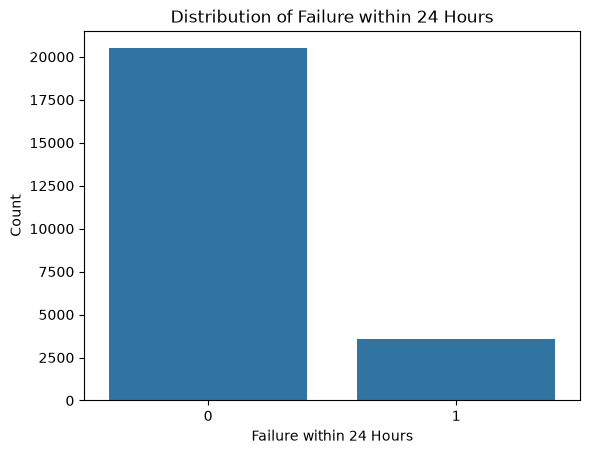

In [17]:
sns.countplot(data=df, x="failure_within_24h")
plt.title("Distribution of Failure within 24 Hours")
plt.xlabel("Failure within 24 Hours")
plt.ylabel("Count")
plt.show()

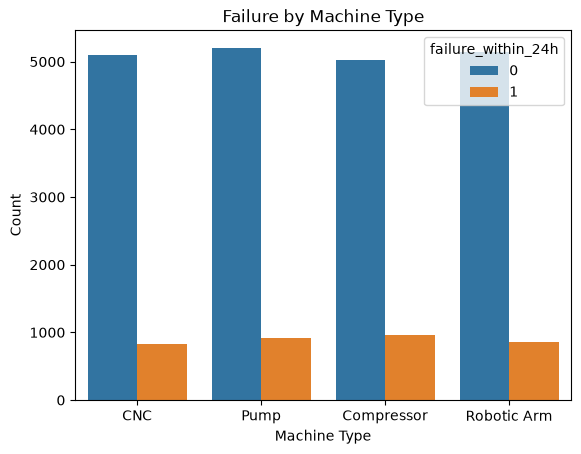

In [18]:
sns.countplot(data=df, x="machine_type", hue="failure_within_24h")
plt.title("Failure by Machine Type")
plt.xlabel("Machine Type")
plt.ylabel("Count")  
plt.show()

In [19]:
failure_rate = df.groupby("machine_type")["failure_within_24h"].mean() * 100

failure_rate

machine_type
CNC            14.047499
Compressor     15.998664
Pump           14.932941
Robotic Arm    14.242879
Name: failure_within_24h, dtype: float64

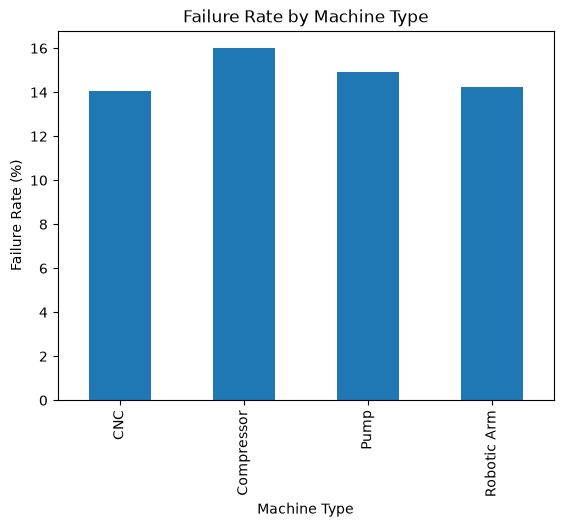

In [20]:
failure_rate.plot(kind="bar")

plt.title("Failure Rate by Machine Type")
plt.xlabel("Machine Type")
plt.ylabel("Failure Rate (%)")

plt.show()

# Does the machine type make a difference?

Yes, but the difference is relatively small

Failure rates in your dataset:

Machine Type     ->    Failure Rate

Compressor       ->    16.0%

Pump             ->    14.9%

Robotic Arm       ->   14.2%

CNC               ->   14.0%


Conclusion: Machine type has some effect, with compressors having the highest failure rate, but it appears less influential than vibration or temperature.**

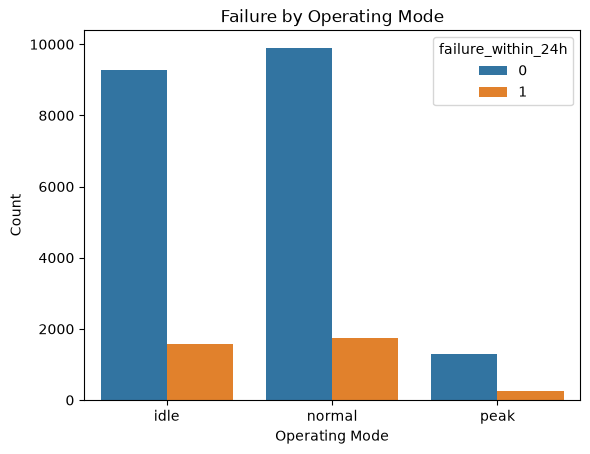

In [21]:
sns.countplot(data=df, x="operating_mode", hue="failure_within_24h")
plt.title("Failure by Operating Mode")
plt.xlabel("Operating Mode")
plt.ylabel("Count")
plt.show()

In [22]:
mode_failure_rate = df.groupby("operating_mode")["failure_within_24h"].mean() * 100

mode_failure_rate

operating_mode
idle      14.490886
normal    14.941541
peak      16.020672
Name: failure_within_24h, dtype: float64

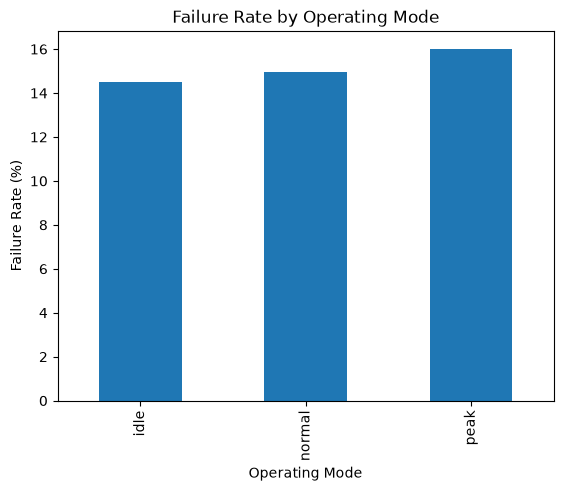

In [23]:
mode_failure_rate.plot(kind="bar")

plt.title("Failure Rate by Operating Mode")
plt.xlabel("Operating Mode")
plt.ylabel("Failure Rate (%)")

plt.show()

# Does the operating mode affect machine failure?

Yes, but only slightly

Operating Mode  ->  Failure Rate

Peak  ->  16.0%

Normal  ->  14.9%

Idle  ->  14.5%

Conclusion: Peak operation has a somewhat higher failure rate, so Operating Mode can help the model, but it probably isn't one of the strongest predictors by itself.

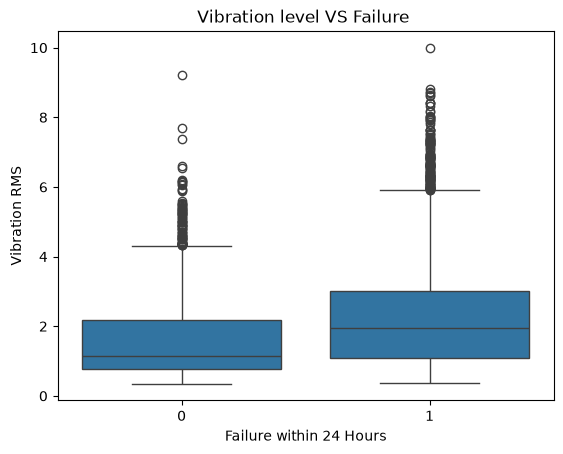

In [24]:
sns.boxplot(data=df, x="failure_within_24h", y="vibration_rms")
plt.title("Vibration level VS Failure ")
plt.xlabel("Failure within 24 Hours")
plt.ylabel("Vibration RMS") 
plt.show()

# Is vibration related to machine failure?

Yes, strongly.

Average vibration when there is no failure: 1.50

Average vibration when there is a failure: 2.31

So, machines experiencing failure have noticeably higher vibration.

Conclusion: Vibration is an important predictor of failure.

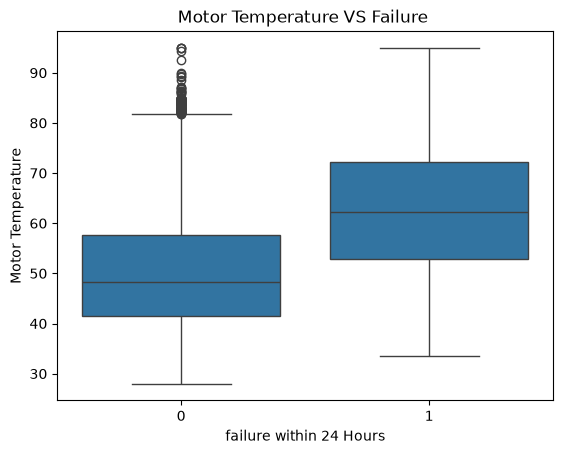

<Axes: xlabel='failure_within_24h', ylabel='temperature_motor'>

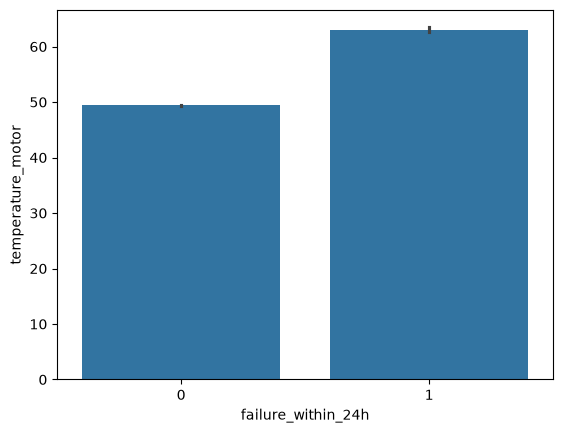

In [25]:
sns.boxplot(data=df , x="failure_within_24h", y="temperature_motor"),
plt.title("Motor Temperature VS Failure "),
plt.xlabel("failure within 24 Hours"),
plt.ylabel("Motor Temperature"),
plt.show()
sns.barplot(data=df , x="failure_within_24h", y="temperature_motor")

# Is high temperature associated with machine failure? 
Yes, very strongly.

That's a large difference.

Conclusion: Higher motor temperature is strongly associated with failure and is likely to be one of the most important features.

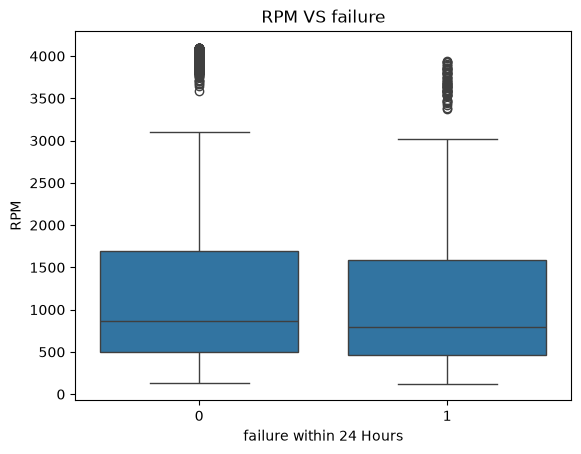

<Axes: xlabel='failure_within_24h', ylabel='rpm'>

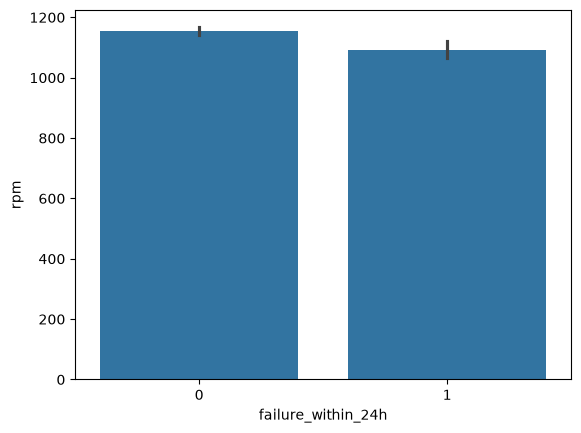

In [26]:
sns.boxplot(data=df , x="failure_within_24h", y="rpm")
plt.title("RPM VS failure")
plt.xlabel("failure within 24 Hours")
plt.ylabel("RPM")
plt.show()
sns.barplot(data=df , x="failure_within_24h", y="rpm")

# Does RPM have a significant relationship with machine failure?
 No, RPM does not appear to have a strong relationship with machine failure.

From the graph:

No failure (0): Average RPM ≈ 1,150


Failure (1): Average RPM ≈ 1,090

The difference is relatively small.

Conclusion: RPM has a relatively weak relationship with machine failure compared with factors such as temperature and vibration. Therefore, RPM may be less important as a predictor of failur

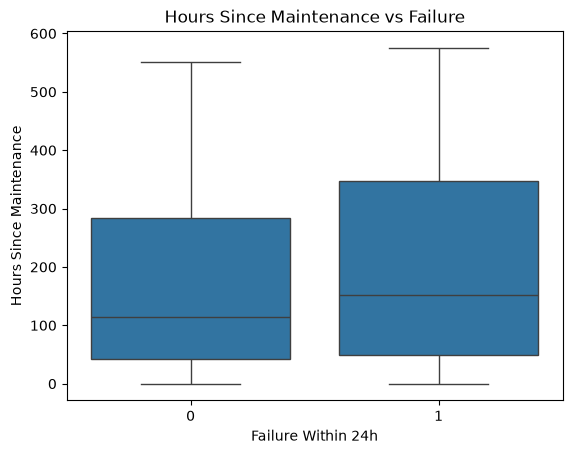

<Axes: xlabel='failure_within_24h', ylabel='hours_since_maintenance'>

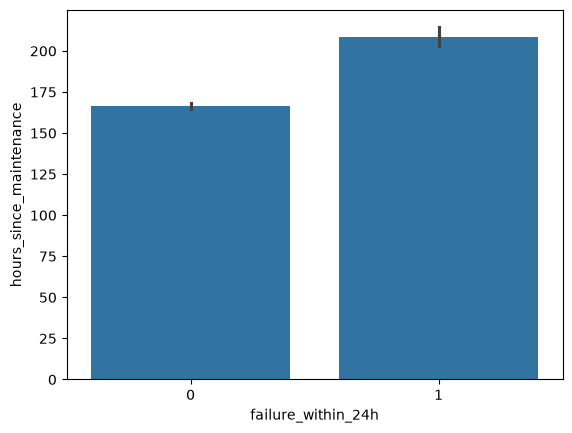

In [27]:
sns.boxplot(data=df, x="failure_within_24h", y="hours_since_maintenance")

plt.title("Hours Since Maintenance vs Failure")
plt.xlabel("Failure Within 24h")
plt.ylabel("Hours Since Maintenance")

plt.show()
sns.barplot(data=df, x="failure_within_24h", y="hours_since_maintenance")

# Does the number of operating hours since the last maintenance affect failure?
Yes,    No failure: 166.4 hours since maintenance on average

Failure: 208.6 hours on average

So machines that have gone longer without maintenance tend to have more failures.

Conclusion: hours_since_maintenance is an important predictive feature.

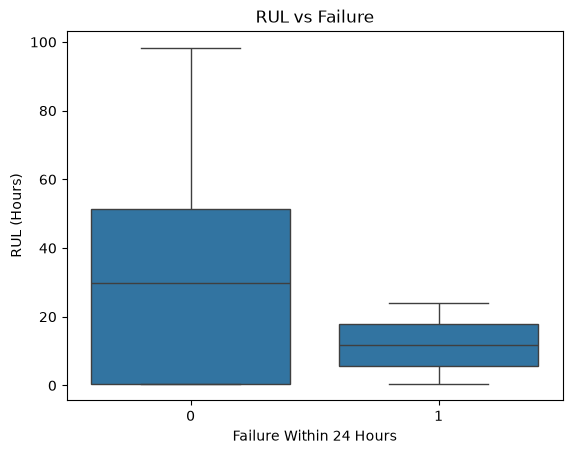

<Axes: xlabel='failure_within_24h', ylabel='rul_hours'>

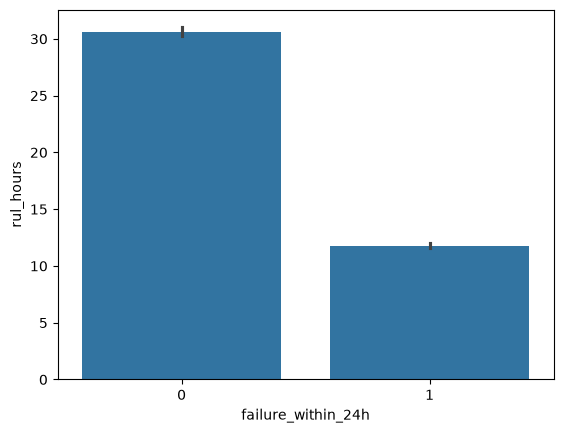

In [28]:
sns.boxplot(data=df, x="failure_within_24h", y="rul_hours")
plt.title("RUL vs Failure")
plt.xlabel("Failure Within 24 Hours")
plt.ylabel("RUL (Hours)")
plt.show()
sns.barplot(data=df, x="failure_within_24h", y="rul_hours")

# Does Remaining Useful Life (RUL) affect the probability of machine failure?

Yes, strongly.

Machines with a lower RUL are much more likely to experience a failure within the next 24 hours.

Conclusion:

rul_hours is a strong predictive feature and can be used as an early warning indicator.

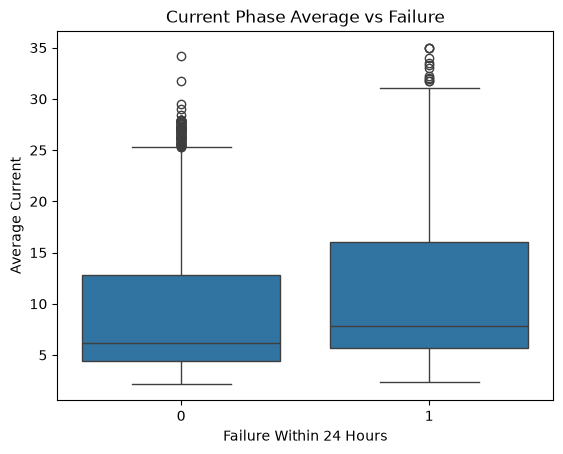

<Axes: xlabel='failure_within_24h', ylabel='current_phase_avg'>

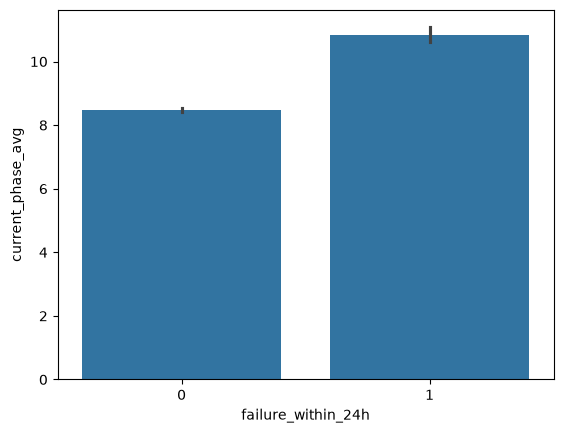

In [29]:
sns.boxplot(data=df, x="failure_within_24h", y="current_phase_avg")
plt.title("Current Phase Average vs Failure")
plt.xlabel("Failure Within 24 Hours")
plt.ylabel("Average Current")
plt.show()
sns.barplot(data=df, x="failure_within_24h", y="current_phase_avg")

# Does current affect machine failure?

Yes, there is a clear relationship.

Higher current is related to a higher chance of machine failure.

Conclusion:
Current is a useful feature for predicting machine failure because machines with higher current tend to fail more often.

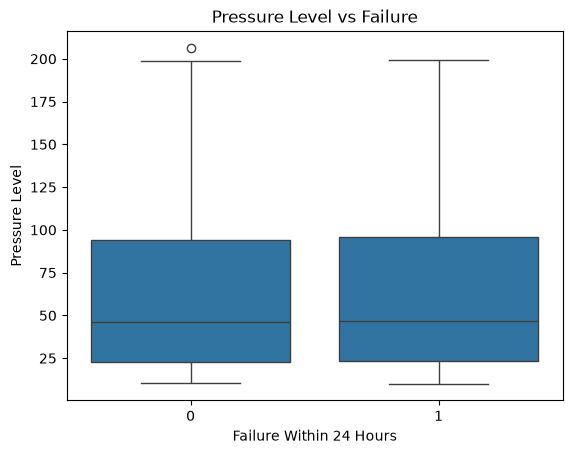

<Axes: xlabel='failure_within_24h', ylabel='pressure_level'>

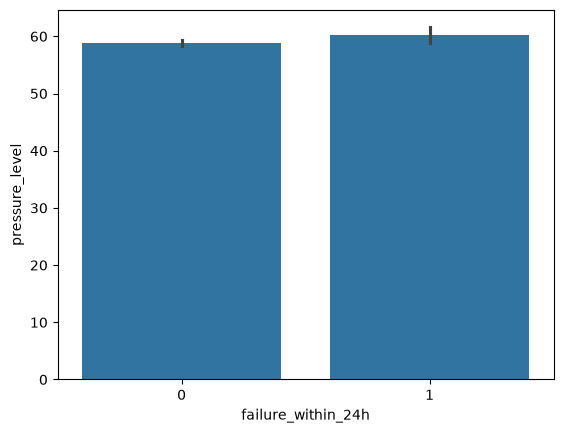

In [30]:
sns.boxplot(data=df, x="failure_within_24h", y="pressure_level")
plt.title("Pressure Level vs Failure")
plt.xlabel("Failure Within 24 Hours")
plt.ylabel("Pressure Level")
plt.show()
sns.barplot(data=df, x="failure_within_24h", y="pressure_level")

# Does pressure level have a strong relationship with machine failure?

Not strongly.

Conclusion:

Pressure level shows only a weak relationship with failure, so it may be less important than other machine-condition variables.

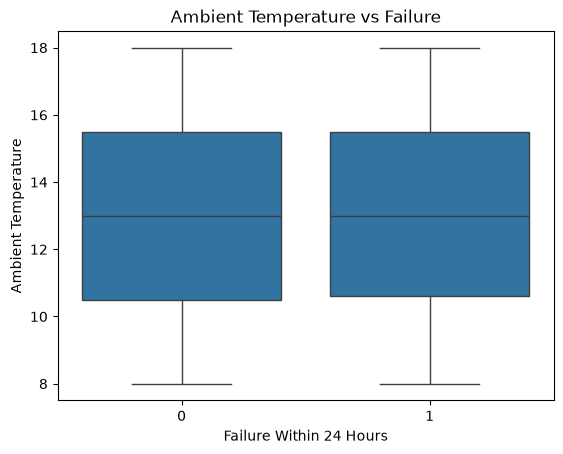

<Axes: xlabel='failure_within_24h', ylabel='ambient_temp'>

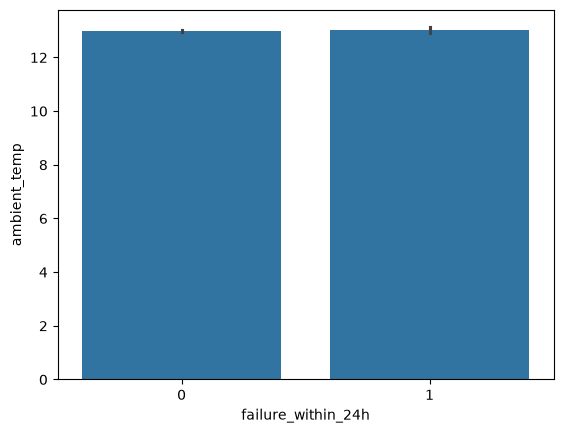

In [31]:
sns.boxplot(data=df, x="failure_within_24h", y="ambient_temp")
plt.title("Ambient Temperature vs Failure")
plt.xlabel("Failure Within 24 Hours")
plt.ylabel("Ambient Temperature")
plt.show()
sns.barplot(data=df, x="failure_within_24h", y="ambient_temp")

# Does ambient temperature affect machine failure?

No significant relationship appears in the data.

The difference is almost weak.

Conclusion:

Ambient temperature does not appear to be an important predictor of machine failure in this dataset.

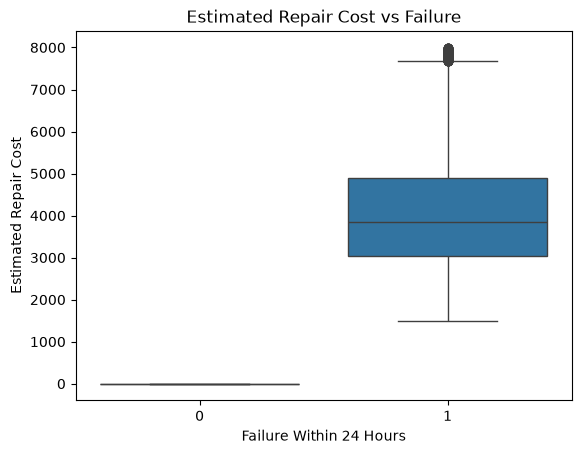

<Axes: xlabel='failure_within_24h', ylabel='estimated_repair_cost'>

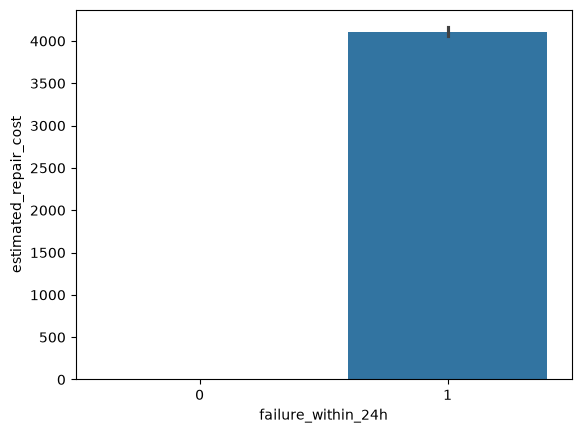

In [32]:
sns.boxplot(data=df, x="failure_within_24h", y="estimated_repair_cost")
plt.title("Estimated Repair Cost vs Failure")
plt.xlabel("Failure Within 24 Hours")
plt.ylabel("Estimated Repair Cost")
plt.show()
sns.barplot(data=df, x="failure_within_24h", y="estimated_repair_cost")

# How does machine failure affect the estimated repair cost?

The relationship is very strong.

Conclusion:

Machine failures are associated with significant repair costs. Therefore, predicting failures in advance could help reduce unexpected maintenance expenses and improve maintenance planning.

# preprocessing + imbalance

In [33]:
df["timestamp"] = pd.to_datetime(df["timestamp"])

df["hour"] = df["timestamp"].dt.hour
df["day_of_week"] = df["timestamp"].dt.dayofweek
df["month"] = df["timestamp"].dt.month

In [34]:
df["temperature_difference"] = (
    df["temperature_motor"] - df["ambient_temp"]
)

In [35]:
df["vibration_rpm_ratio"] = (
    df["vibration_rms"] / (df["rpm"] + 1)
)

In [36]:
df["current_rpm_ratio"] = (
    df["current_phase_avg"] / (df["rpm"] + 1)
)

In [37]:
df["pressure_rpm_ratio"] = (
    df["pressure_level"] / (df["rpm"] + 1)
)

In [38]:
df["maintenance_load"] = (
    df["hours_since_maintenance"] * df["rpm"]
)

In [39]:
X = df.drop(
    columns=[
        "rul_hours",
        "failure_type",
        "estimated_repair_cost",
        "timestamp",
        "failure_within_24h",
        "machine_id"
    ]
)

In [40]:
y = df["failure_within_24h"]

In [41]:
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [42]:
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full,
    y_train_full,
    test_size=0.20,
    random_state=42,
    stratify=y_train_full
)

In [43]:
len(X_train)

15386

In [44]:
len(X_val)

3847

In [45]:
len(X_test)

4809

In [46]:
categorical_features = X_train.select_dtypes(
    include=["object"]
).columns.tolist()

C:\Users\10\AppData\Local\Temp\ipykernel_6512\2891102020.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X_train.select_dtypes(


In [47]:
numerical_features = X_train.select_dtypes(
    exclude=["object"]
).columns.tolist()

In [48]:
numerical_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)


In [49]:
categorical_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "onehot",
            OneHotEncoder(handle_unknown="ignore")
        )
    ]
)

In [50]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            numerical_pipeline,
            numerical_features
        ),
        (
            "cat",
            categorical_pipeline,
            categorical_features
        )
    ]
)


# Extra Trees

In [51]:
extra_trees_pipeline = Pipeline(
    steps=[
        ("preprocessing", preprocessor),
        ("model", ExtraTreesClassifier(
            class_weight="balanced",
            random_state=42,
            n_jobs=-1
        ))
    ]
)

In [52]:
extra_trees_params = {
    "model__n_estimators": [200, 300, 500],
    "model__max_depth": [None, 10, 20, 30],
    "model__min_samples_leaf": [1, 2, 4],
    "model__max_features": ["sqrt", "log2", None]
}


In [53]:
extra_trees_grid = GridSearchCV(
    extra_trees_pipeline,
    extra_trees_params,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

In [54]:
extra_trees_grid.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__max_depth': [None, 10, ...], 'model__max_features': ['sqrt', 'log2', ...], 'model__min_samples_leaf': [1, 2, ...], 'model__n_estimators': [200, 300, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Su

In [55]:
extra_trees_model = extra_trees_grid.best_estimator_

In [56]:
extra_trees_grid.best_params_

{'model__max_depth': 20,
 'model__max_features': 'sqrt',
 'model__min_samples_leaf': 1,
 'model__n_estimators': 500}

In [57]:
extra_trees_pred = extra_trees_model.predict(X_test)

In [58]:
extra_trees_accuracy = accuracy_score(y_test, extra_trees_pred)
extra_trees_precision = precision_score(y_test, extra_trees_pred, zero_division=0)
extra_trees_recall = recall_score(y_test, extra_trees_pred, zero_division=0)
extra_trees_f1 = f1_score(y_test, extra_trees_pred, zero_division=0)

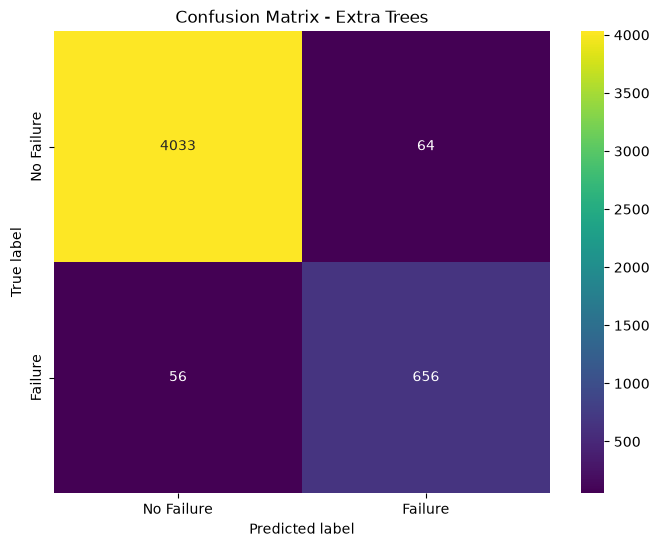

In [59]:
cm = confusion_matrix(y_test, extra_trees_grid.predict(X_test))

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="viridis",
    xticklabels=["No Failure", "Failure"],
    yticklabels=["No Failure", "Failure"]
)

plt.title("Confusion Matrix - Extra Trees")
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.show()

# CATBOOST

In [60]:
catboost_pipeline = Pipeline(
    steps=[
        ("preprocessing", preprocessor),
        ("model", CatBoostClassifier(
            verbose=0,
            random_seed=42,
            thread_count=-1,
            auto_class_weights="Balanced"
        ))
    ]
)

In [61]:
catboost_params = {
    "model__iterations": [200, 400, 600],
    "model__depth": [4, 6, 8],
    "model__learning_rate": [0.03, 0.05, 0.1],
    "model__l2_leaf_reg": [1, 3, 5]
}

In [62]:
catboost_grid = GridSearchCV(
    catboost_pipeline,
    catboost_params,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

In [63]:
catboost_grid.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step... verbose=0))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__depth': [4, 6, ...], 'model__iterations': [200, 400, ...], 'model__l2_leaf_reg': [1, 3, ...], 'model__learning_rate': [0.03, 0.05, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable

In [64]:
catboost_model = catboost_grid.best_estimator_

In [65]:
catboost_grid.best_params_

{'model__depth': 6,
 'model__iterations': 600,
 'model__l2_leaf_reg': 1,
 'model__learning_rate': 0.1}

In [66]:
catboost_pred = catboost_model.predict(X_test)

In [67]:
catboost_accuracy = accuracy_score(y_test, catboost_pred)
catboost_precision = precision_score(y_test, catboost_pred, zero_division=0)
catboost_recall = recall_score(y_test, catboost_pred, zero_division=0)
catboost_f1 = f1_score(y_test, catboost_pred, zero_division=0)

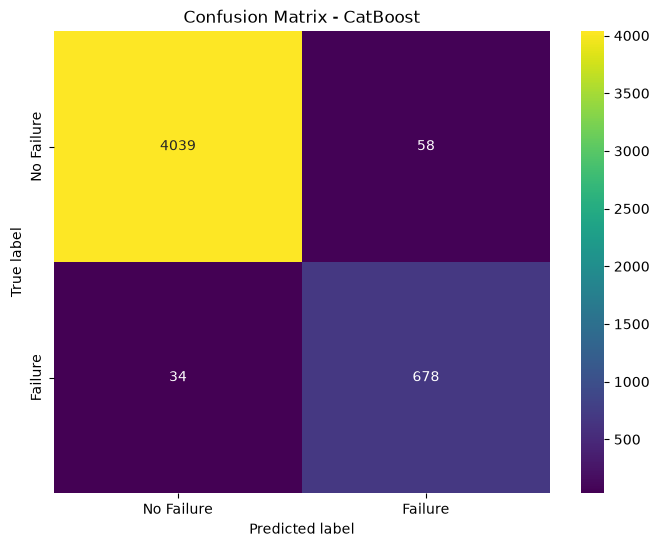

In [68]:
cm = confusion_matrix(y_test, catboost_grid.predict(X_test))

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="viridis",
    xticklabels=["No Failure", "Failure"],
    yticklabels=["No Failure", "Failure"]
)

plt.title("Confusion Matrix - CatBoost")
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.show()

# MLP (Multi-Layer Perceptron)

In [69]:
mlp_model = Pipeline(
    steps=[
        ("preprocessing", preprocessor),
        ("model", MLPClassifier(
            hidden_layer_sizes=(128, 64),
            activation="relu",
            alpha=0.001,
            learning_rate_init=0.001,
            max_iter=500,
            early_stopping=True,
            validation_fraction=0.1,
            random_state=42
        ))
    ]
)

In [70]:
mlp_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessing', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](17,)","['machine_type','vibration_rms','temperature_motor',..., 'current_rpm_ratio','pressure_rpm_ratio','maintenance_load']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,17
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).

In [71]:
mlp_pred = mlp_model.predict(X_test)

In [72]:
mlp_accuracy = accuracy_score(y_test, mlp_pred)
mlp_precision = precision_score(y_test, mlp_pred, zero_division=0)
mlp_recall = recall_score(y_test, mlp_pred, zero_division=0)
mlp_f1 = f1_score(y_test, mlp_pred, zero_division=0)

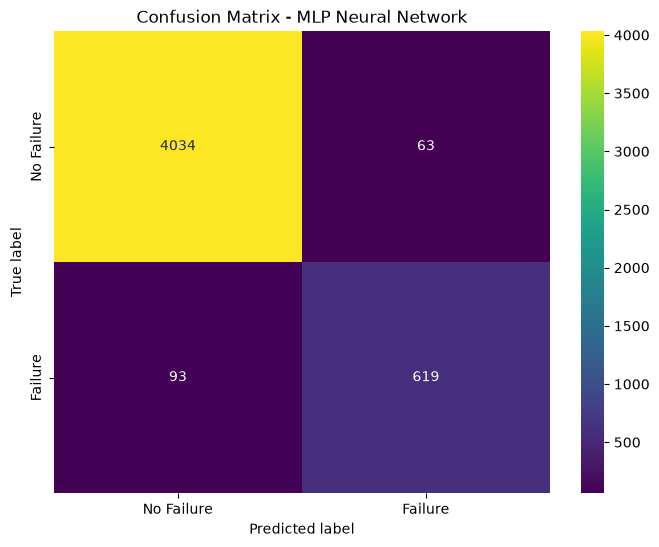

In [73]:
cm = confusion_matrix(y_test, mlp_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="viridis",
    xticklabels=["No Failure", "Failure"],
    yticklabels=["No Failure", "Failure"]
)

plt.title("Confusion Matrix - MLP Neural Network")
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.show()

# XGBOOST

In [74]:
negative_class = (y_train == 0).sum()
positive_class = (y_train == 1).sum()

In [75]:
scale_pos_weight = negative_class / positive_class

In [76]:
xgb_pipeline = Pipeline(
    steps=[
        (
            "preprocessing",
            preprocessor
        ),
        (
            "model",
            XGBClassifier(
                scale_pos_weight=scale_pos_weight,
                eval_metric="logloss",
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

In [77]:
xgb_params = {
    "model__n_estimators": [100, 200, 300],
    "model__max_depth": [3, 5, 7],
    "model__learning_rate": [0.01, 0.05, 0.1],
    "model__subsample": [0.8, 1.0]
}

In [78]:
xgb_grid = GridSearchCV(
    xgb_pipeline,
    xgb_params,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

In [79]:
xgb_grid.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...=None, ...))])"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__learning_rate': [0.01, 0.05, ...], 'model__max_depth': [3, 5, ...], 'model__n_estimators': [100, 200, ...], 'model__subsample': [0.8, 1.0]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for cal

In [80]:
xgb_model = xgb_grid.best_estimator_

In [81]:
xgb_grid.best_params_

{'model__learning_rate': 0.1,
 'model__max_depth': 7,
 'model__n_estimators': 300,
 'model__subsample': 1.0}

In [82]:
xgb_pred = xgb_model.predict(X_test)

In [83]:
xgb_accuracy = accuracy_score(y_test, xgb_pred)
xgb_precision = precision_score(y_test, xgb_pred, zero_division=0)
xgb_recall = recall_score(y_test, xgb_pred, zero_division=0)
xgb_f1 = f1_score(y_test, xgb_pred, zero_division=0)

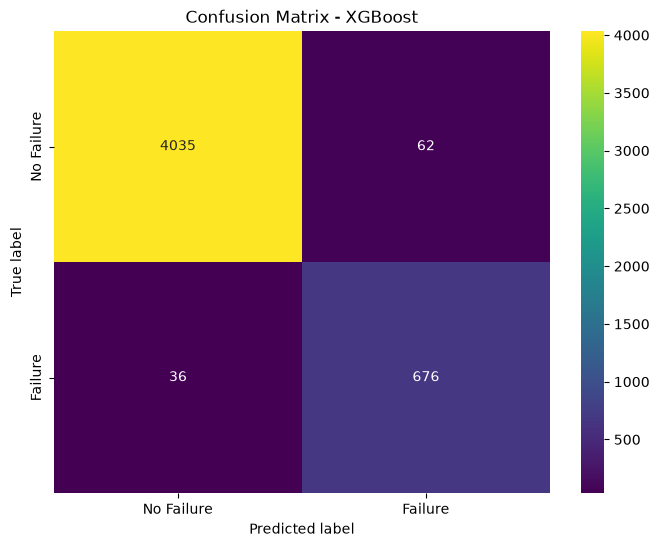

In [84]:
cm = confusion_matrix(y_test, xgb_grid.predict(X_test))

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="viridis",
    xticklabels=["No Failure", "Failure"],
    yticklabels=["No Failure", "Failure"]
)

plt.title("Confusion Matrix - XGBoost")
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.show()

# EVALUTION

In [93]:
print("Extra Trees--->")
print(classification_report(y_test, extra_trees_pred,
target_names=["No Failure", "Failure"]))

print("CatBoost--->")
print(classification_report(y_test, catboost_pred,
target_names=["No Failure", "Failure"]))

print("MLP Neural Network--->")
print(classification_report(y_test, mlp_pred,
target_names=["No Failure", "Failure"]))

print("XGBoost--->")
print(classification_report(y_test, xgb_pred,
target_names=["No Failure", "Failure"]))

Extra Trees--->
              precision    recall  f1-score   support

  No Failure       0.99      0.98      0.99      4097
     Failure       0.91      0.92      0.92       712

    accuracy                           0.98      4809
   macro avg       0.95      0.95      0.95      4809
weighted avg       0.98      0.98      0.98      4809

CatBoost--->
              precision    recall  f1-score   support

  No Failure       0.99      0.99      0.99      4097
     Failure       0.92      0.95      0.94       712

    accuracy                           0.98      4809
   macro avg       0.96      0.97      0.96      4809
weighted avg       0.98      0.98      0.98      4809

MLP Neural Network--->
              precision    recall  f1-score   support

  No Failure       0.98      0.98      0.98      4097
     Failure       0.91      0.87      0.89       712

    accuracy                           0.97      4809
   macro avg       0.94      0.93      0.93      4809
weighted avg       0.9

In [85]:
results_df = pd.DataFrame({
    "Model": [
        "CatBoost",
        "Extra Trees",
        "MLP Neural Network",
        "XGBoost"
    ],
    
    "Accuracy": [
        catboost_accuracy,
        extra_trees_accuracy,
        mlp_accuracy,
        xgb_accuracy
    ],
    
    "Precision": [
        catboost_precision,
        extra_trees_precision,
        mlp_precision,
        xgb_precision
    ],
    
    "Recall": [
        catboost_recall,
        extra_trees_recall,
        mlp_recall,
        xgb_recall
    ],
    
    "F1 Score": [
        catboost_f1,
        extra_trees_f1,
        mlp_f1,
        xgb_f1
    ]
})

results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,CatBoost,0.980869,0.921196,0.952247,0.936464
1,Extra Trees,0.975047,0.911111,0.921348,0.916201
2,MLP Neural Network,0.967561,0.907625,0.869382,0.888092
3,XGBoost,0.979622,0.915989,0.949438,0.932414


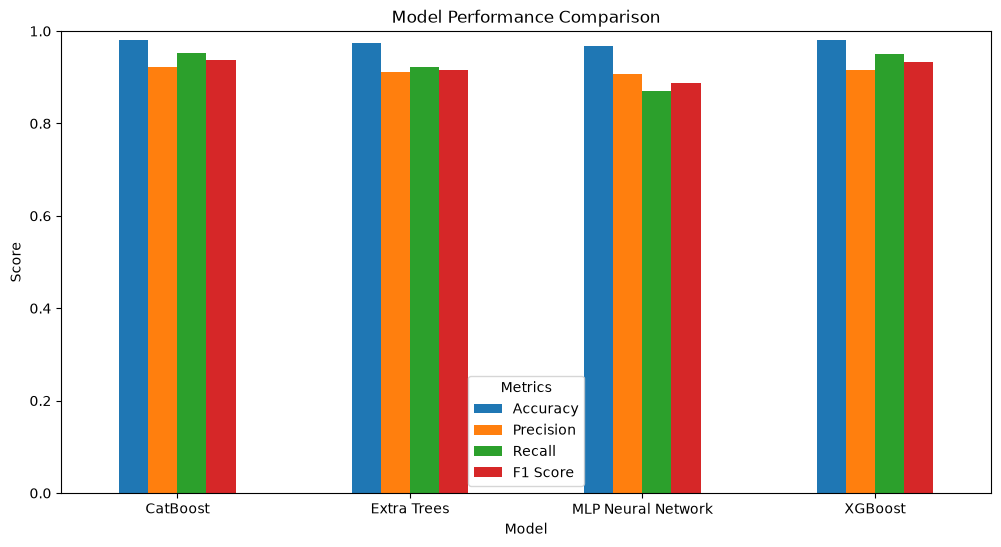

In [86]:
results_plot = results_df.set_index("Model")

results_plot.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Model Performance Comparison")
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(title="Metrics")
plt.show()

# save the model

In [87]:
joblib.dump(catboost_model,"model.pkl")
print("Model saved successfully!")

Model saved successfully!
